ARTI308 - Machine Learning
# Lab 3 Assignment: Exploratory Data Analysis (EDA)
## Dataset: Telco Customer Churn

In this assignment, the EDA techniques covered in Lab 3 are applied to the **Telco Customer Churn** dataset.

**About the dataset:** Each row represents a single telecom customer. The columns describe the customer's demographics (gender, senior citizen status, partner, dependents), the services they subscribe to (phone, internet, online security, streaming, etc.), account information (contract type, payment method, tenure, monthly/total charges), and whether the customer **churned** (left the company) or not. This is a classic business dataset used to study and predict customer churn.

- 7,043 customers (rows), 21 columns
- Target column: `Churn` (Yes / No)
- Source: IBM Sample Data Sets (widely used on Kaggle)
- Dataset file submitted with this notebook: `WA_Fn-UseC_-Telco-Customer-Churn.csv`


## 1. Loading the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset consists of individual customer records, where each row represents one telecom customer.
The columns describe demographic attributes, subscribed services, account/contract information, and billing amounts, ending with the `Churn` label.
From the first few rows, we can observe a mix of categorical (text) columns such as `gender` and `Contract`, and numerical columns such as `tenure` and `MonthlyCharges`.

## 2. Data type of columns

In [ ]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

The data type inspection shows that most columns are stored as `object` (text), which is expected for categorical fields like `Contract`, `PaymentMethod`, and the various Yes/No service columns. `SeniorCitizen`, `tenure`, and `MonthlyCharges` are correctly stored as numeric types. However, `TotalCharges` is stored as `object` instead of a numeric type, which is a formatting issue that needs to be corrected before it can be used in calculations or models.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes['TotalCharges']

dtype('float64')

`TotalCharges` has been converted to a numeric (`float64`) type using `pd.to_numeric` with `errors='coerce'`, which turns any value that cannot be converted into a missing value (`NaN`) instead of raising an error. This is important, because some values in this column were blank strings rather than numbers, as we will confirm in the missing values check below. Correcting data types at this stage improves the reliability of subsequent numerical analysis.

## 3. Check Missing Values

In [ ]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The missing values check shows that, after the type conversion above, the `TotalCharges` column now has a small number of missing values, while all other columns are complete. These missing values were originally stored as blank strings rather than an explicit `NaN`, which is why they were not detected before the type conversion. This highlights why checking column types carefully matters — a missing-value check performed on the raw `object` column would have missed this issue entirely.

In [ ]:
df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Investigating these rows shows that all of them have a `tenure` of 0, meaning these are brand-new customers who have not yet been billed a full cycle. This makes the missing `TotalCharges` values logically explainable rather than a data error, and a reasonable approach is to fill them with 0 (since no charges have accrued yet) rather than dropping the rows.

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isna().sum()

np.int64(0)

## 4. Check duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset. Since each row is tied to a unique `customerID`, duplicate rows would have suggested a data export or merging error that needed to be investigated before analysis.

## 5. Number of rows and columns

In [ ]:
df.shape

(7043, 21)

The dataset consists of **7,043 rows and 21 columns**. This is a reasonably sized dataset for exploratory analysis and for later training a churn prediction model, without being computationally expensive to work with.

## 6. Descriptive Summary Statistics

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


The descriptive statistics for the numerical columns show that `tenure` ranges from 0 to 72 months, and `MonthlyCharges` ranges from about $18 to $119. The mean `TotalCharges` is noticeably higher than the median, which suggests the distribution is right-skewed — a small number of long-tenure customers have accumulated very high total charges.

In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


The descriptive statistics for the categorical columns confirm that most service-related columns (e.g. `OnlineSecurity`, `TechSupport`) have a small number of unique categories (typically Yes/No/No internet service), while `PaymentMethod` and `Contract` have a few distinct billing options. The `customerID` column has 7,043 unique values as expected, since it is a unique identifier and not a useful feature for analysis or modeling.

## 7. Target Class Distribution (Churn)

In [ ]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

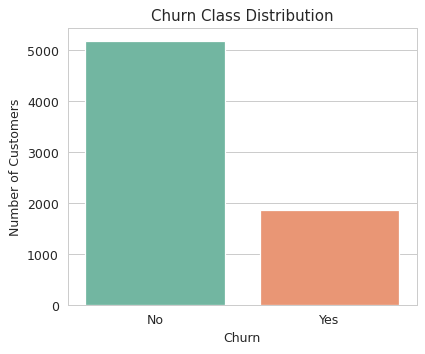

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

The dataset is imbalanced: roughly 73% of customers did not churn, while about 27% did. This is important to keep in mind for any future modeling step, since a model could achieve high accuracy just by always predicting "No churn", so evaluation metrics beyond accuracy (such as recall or F1-score for the churn class) would be more meaningful.

## 8. Univariate Analysis

### Distribution of Tenure

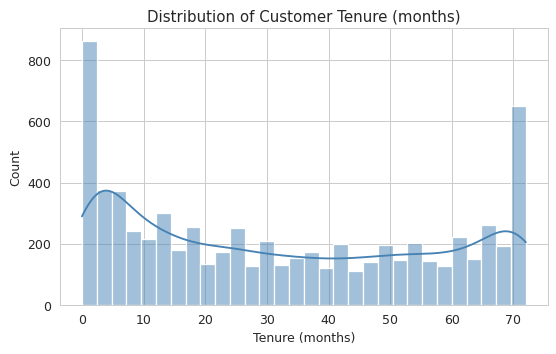

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['tenure'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Customer Tenure (months)')
plt.xlabel('Tenure (months)')
plt.show()

The tenure distribution is notably bimodal, with a large group of very new customers (close to 0 months) and another sizeable group of long-tenured customers (close to 72 months). This suggests two distinct customer populations: those who churn quickly after joining, and a loyal base that stays for years.

### Distribution of Monthly Charges

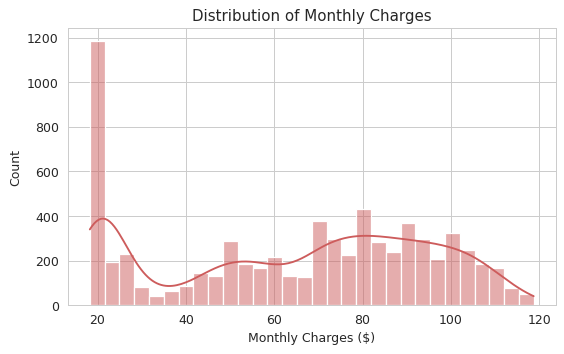

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['MonthlyCharges'], kde=True, bins=30, color='indianred')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.show()

The `MonthlyCharges` distribution shows a large cluster of customers paying around $20 (likely phone-only customers) and a broader, flatter spread of customers paying between $60-$100, who likely subscribe to internet and streaming add-ons. This bimodal shape reflects the tiered nature of the telecom pricing plans.

## 9. Bivariate Analysis

### Churn by Contract Type

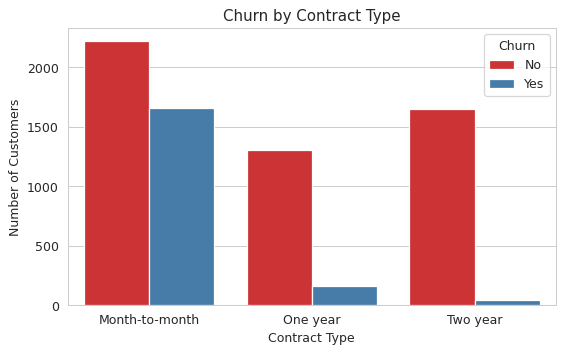

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Customers on a **month-to-month** contract churn far more often, both in absolute numbers and proportionally, than customers on one-year or two-year contracts. This strongly suggests that contract length is one of the most important factors related to churn, likely because month-to-month customers face no penalty for leaving at any time.

### Tenure by Churn

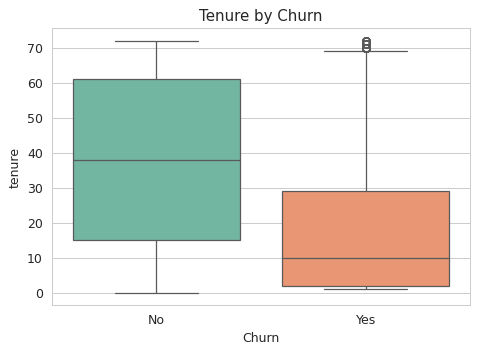

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set2', legend=False)
plt.title('Tenure by Churn')
plt.show()

Customers who churned have a much lower median tenure than customers who stayed, confirming that churn tends to happen earlier in the customer relationship. This reinforces the earlier finding from the tenure distribution and suggests that the first several months are a critical period for customer retention efforts.

### Monthly Charges by Churn

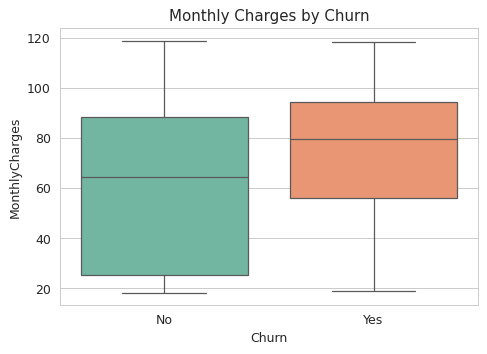

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn')
plt.show()

Customers who churned tend to have somewhat **higher** monthly charges than those who stayed. Combined with the contract finding above, this suggests that customers paying more per month on flexible, no-commitment plans are the group most likely to leave, possibly due to price sensitivity or dissatisfaction with the cost of their plan.

### Churn by Internet Service Type

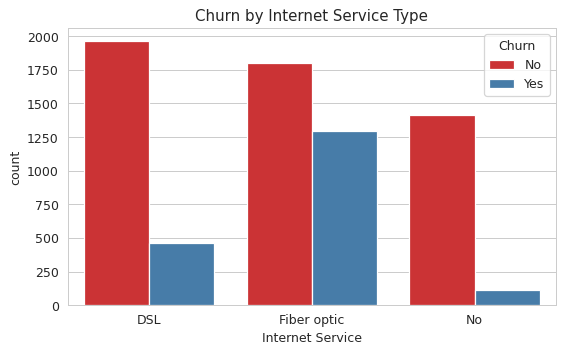

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.show()

Customers with **Fiber optic** internet churn at a noticeably higher rate than those with DSL or no internet service. This could reflect higher expectations (and higher prices) for fiber customers, or possible service quality issues, and would be worth investigating further with the business team.

## 10. Correlation Matrix

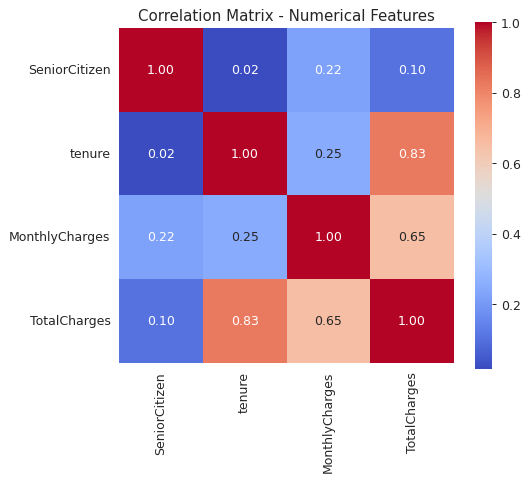

In [ ]:
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix - Numerical Features')
plt.show()

`tenure` and `TotalCharges` are strongly positively correlated (as expected, since total charges accumulate the longer a customer stays). `MonthlyCharges` is also positively correlated with `TotalCharges`, but more weakly, since total charges depend on both the monthly rate and how long the customer has been billed. `SeniorCitizen` shows very weak correlation with the other numerical features, meaning it captures largely independent information.

## 11. Time-Related / Tenure-Based Analysis

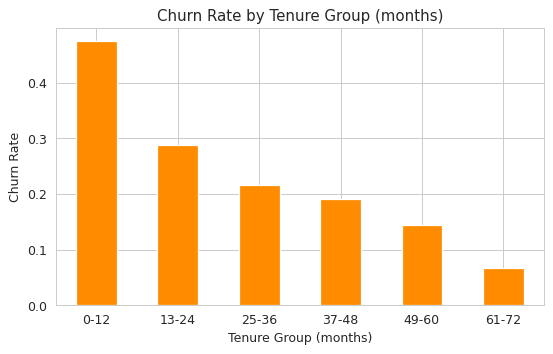

In [ ]:
tenure_bins = pd.cut(df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
                      labels=['0-12','13-24','25-36','37-48','49-60','61-72'])
churn_rate = df.groupby(tenure_bins, observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

plt.figure(figsize=(7,4))
churn_rate.plot(kind='bar', color='darkorange')
plt.title('Churn Rate by Tenure Group (months)')
plt.xlabel('Tenure Group (months)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

The churn rate drops sharply as tenure increases: customers in their first year churn at the highest rate, while customers who have stayed 5-6 years churn only rarely. This "early-tenure risk" pattern is a common finding in subscription businesses and suggests that retention efforts (such as onboarding support or introductory offers) should be concentrated on customers in their first 12 months.

## Conclusion

Applying the EDA workflow from Lab 3 to the Telco Customer Churn dataset shows that:

- `TotalCharges` needed a data type fix: it was stored as text and contained 11 blank values, all belonging to brand-new customers with `tenure = 0`, which were filled with 0 after conversion.
- No duplicate rows were found in the dataset.
- The target class `Churn` is imbalanced (about 27% churn vs 73% no-churn), which should be taken into account for future modeling.
- **Contract type** is strongly related to churn: month-to-month customers churn far more than customers on annual contracts.
- **Tenure** is strongly related to churn: customers who churn tend to leave early in their relationship with the company, with risk dropping steadily the longer they stay.
- Customers with **higher monthly charges** and **fiber optic internet** also show higher churn rates, suggesting price and service-type sensitivity.
- `tenure` and `TotalCharges` are strongly correlated, as expected.

These findings suggest that a churn-prediction model could realistically use contract type, tenure, internet service type, and monthly charges as strong predictive features.

End of Assignment.